# Análise dos logs

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
def plot_congestion_control(df):
    df_plot = df.copy()
    df_plot['tempo_relativo'] = df_plot['tempo'] - df_plot['tempo'].min()
    
    fig, ax = plt.subplots(figsize=(15, 6)) # Aumentei a largura para caber mais pontos
    
    ax.plot(df_plot['tempo_relativo'], df_plot['cwnd'], label='CWND', color='#1f77b4', marker='o', markersize=3)
    ax.step(df_plot['tempo_relativo'], df_plot['ssthresh'], label='SSTHRESH', color='#d62728', linestyle='--')

    # Define um tick a cada 0.1 segundos (ou ajuste conforme sua necessidade)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1)) 
    # Define subdivisões menores (opcional)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    
    # Rotaciona para não sobrepor os números
    plt.xticks(rotation=90, fontsize=8) 
    
    ax.set_title('CWND vs SSTHRESH')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Tamanho da Janela (Bytes)')
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()
    
def plot_sequence_progression(df):
    """
    Gráfico de Stevens (Tempo x Sequência).
    Mostra o progresso dos dados e as retransmissões.
    """
    df_plot = df.copy()
    df_plot['tempo_relativo'] = df_plot['tempo'] - df_plot['tempo'].min()
    
    envios = df_plot[df_plot['evento'] == 'ENVIO']
    acks = df_plot[df_plot['evento'] == 'ACK']

    plt.figure(figsize=(10, 5))
    plt.scatter(envios['tempo_relativo'], envios['seq'], label='Pacote Enviado (Seq)', color='#2ca02c', s=15, alpha=0.6)
    plt.step(acks['tempo_relativo'], acks['ack'], label='Confirmação Recebida (ACK)', color='#ff7f0e', where='post', linewidth=1.5)

    plt.title('Progressão de Números de Sequência e ACKs')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Número de Sequência (Bytes)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [55]:
data = pd.read_csv('client_log.csv')

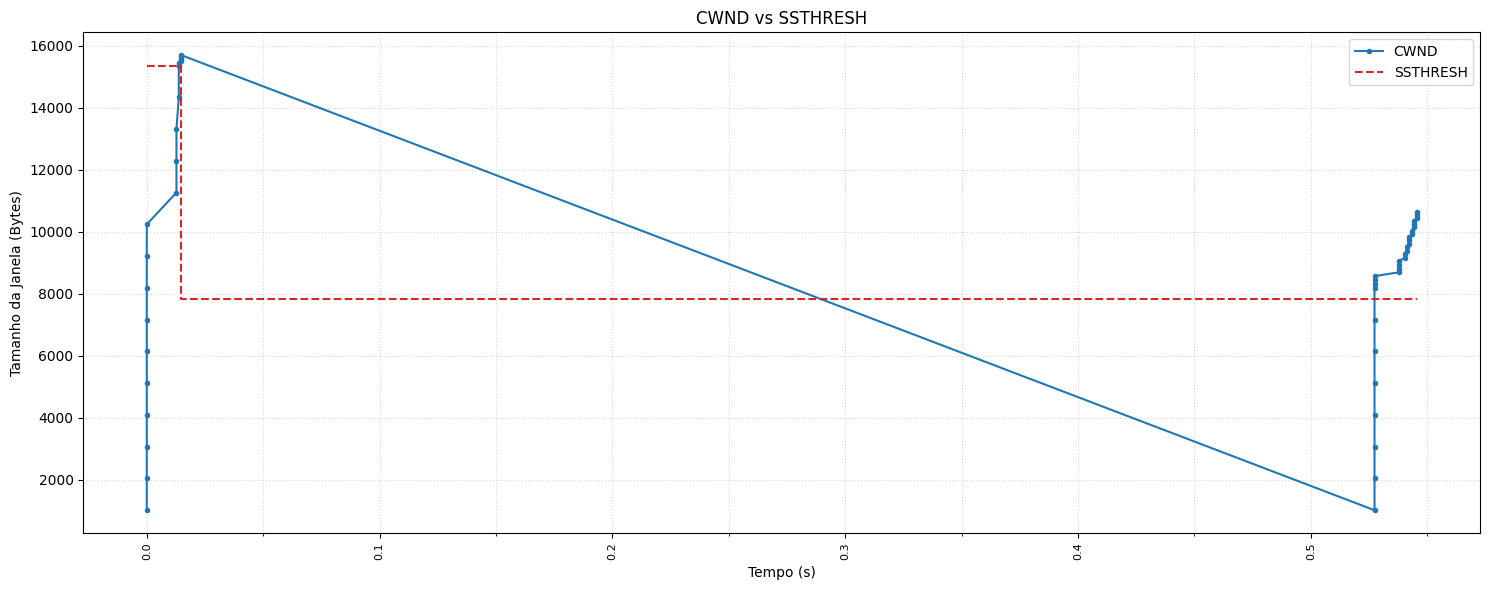

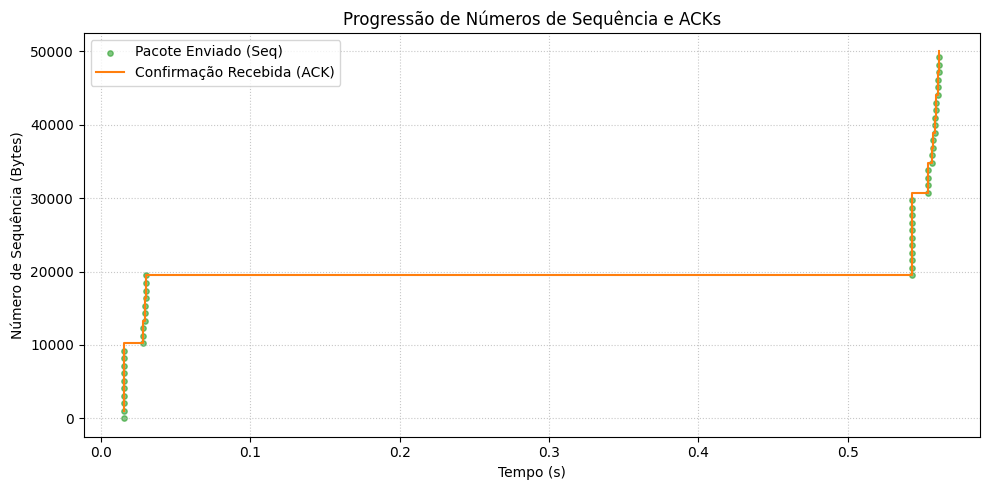

In [56]:
plot_congestion_control(data[data['evento'].str.contains('ENVIO')])
plot_sequence_progression(data)